<a href="https://colab.research.google.com/github/mkumar312/Agentic-AI-Generative-AI-ML-DA-FSDC_CODES_EXPERTISE/blob/main/program10_fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!nvidia-smi

Sun Feb 15 14:22:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
label_encode = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [6]:
train_df = pd.read_csv('/content/drive/MyDrive/Fashion_mnist/dataset/fashion-mnist_train.csv')
train_df.head(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
test_df = pd.read_csv('/content/drive/MyDrive/Fashion_mnist/dataset/fashion-mnist_test.csv')
test_df.head(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (60000, 785)
Test shape: (10000, 785)


In [9]:
class MNISTDataset(Dataset):
    def __init__(self, data, labels=None, transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx].reshape(28, 28).astype(np.float32)
        image = image / 255.0  # Normalize
        image = torch.tensor(image).unsqueeze(0)  # Add channel dimension

        if self.labels is not None:
            label = torch.tensor(self.labels[idx], dtype=torch.long)
            return image, label
        return image

In [10]:
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

In [11]:
X_test=test_df.drop('label',axis=1).values
y_test=test_df['label'].values

In [12]:
X_train.shape

(60000, 784)

In [13]:
X_test.shape

(10000, 784)

In [14]:
full_dataset = MNISTDataset(X_train, y_train)

In [15]:
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [16]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [17]:
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 54000
Validation samples: 6000


In [18]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout1(x)
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

In [19]:
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [21]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

In [22]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

In [23]:
num_epochs = 10
print(f"\nStarting training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')


Starting training for 10 epochs...
Epoch [1/10]
  Train Loss: 0.6325, Train Acc: 76.83%
  Val Loss: 0.3683, Val Acc: 86.30%
Epoch [2/10]
  Train Loss: 0.4160, Train Acc: 85.30%
  Val Loss: 0.3010, Val Acc: 88.13%
Epoch [3/10]
  Train Loss: 0.3584, Train Acc: 87.11%
  Val Loss: 0.2745, Val Acc: 89.58%
Epoch [4/10]
  Train Loss: 0.3280, Train Acc: 88.17%
  Val Loss: 0.2544, Val Acc: 90.35%
Epoch [5/10]
  Train Loss: 0.3050, Train Acc: 89.08%
  Val Loss: 0.2457, Val Acc: 90.82%
Epoch [6/10]
  Train Loss: 0.2846, Train Acc: 89.74%
  Val Loss: 0.2336, Val Acc: 91.05%
Epoch [7/10]
  Train Loss: 0.2675, Train Acc: 90.39%
  Val Loss: 0.2265, Val Acc: 91.70%
Epoch [8/10]
  Train Loss: 0.2551, Train Acc: 90.65%
  Val Loss: 0.2176, Val Acc: 91.88%
Epoch [9/10]
  Train Loss: 0.2457, Train Acc: 91.16%
  Val Loss: 0.2159, Val Acc: 91.73%
Epoch [10/10]
  Train Loss: 0.2327, Train Acc: 91.49%
  Val Loss: 0.2120, Val Acc: 92.05%


In [24]:
print("\nMaking predictions on test set...")
test_dataset = MNISTDataset(X_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model.eval()
predictions = []

with torch.no_grad():
    for images in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        predictions.extend(predicted.cpu().numpy())


Making predictions on test set...


In [25]:
def visualize_predictions(n=5):
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for i in range(n):
        img = X_test[i].reshape(28, 28)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Predicted: {label_encode[predictions[i]]}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.savefig('sample_predictions.png')
    print("Sample predictions saved as 'sample_predictions.png'")

Sample predictions saved as 'sample_predictions.png'


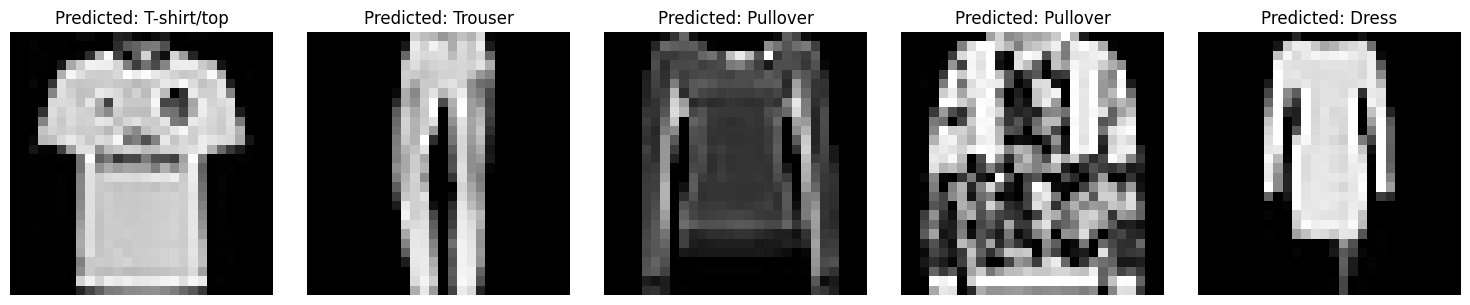

In [28]:
visualize_predictions()